# CAMS-AOD vs AERONET-AOD @ Nghia Do — NE-monsoon dry season

**Question:** Does CAMS reproduce AERONET-observed AOD at Nghia Do (urban Hanoi)
during the Nov-Mar dry season, when continental haze + biomass-burning push
AOD into the >1 regime?

This matters because Stage B treats CAMS as the regional prior. If CAMS is
catastrophically low during haze episodes, no downstream gap-fill/bias-correct
step can rescue it.

Comparisons are raw — no bias correction, no smoothing, no Stage B logic.


In [1]:
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr

# Nghia Do — AERONET site in urban Hanoi
LAT, LON = 21.048, 105.800

# NE-monsoon dry season for northern Vietnam (continental haze window)
DRY_MONTHS = [11, 12, 1, 2, 3]

# Window covered by CAMS reanalysis + AERONET overlap
DATE_START = "2022-09-01"
DATE_END   = "2025-08-30"

AERONET_CSV = "/home/slow_data/Air_Quality/AERONET/process/aod_550/10/NGHIA_DO.csv"
CAMS_GLOB   = "/home/slow_data/Air_Quality/CAM/_monthly_raw/cams_*.nc"


In [2]:
def load_aeronet(csv_path):
    """AERONET file is UTC+7 (Hanoi local, timezone-naive) — convert to UTC."""
    df = pd.read_csv(csv_path, parse_dates=["datetime"])
    df["time_utc"] = df["datetime"] - pd.Timedelta(hours=7)
    return df[["time_utc", "aod_550"]].sort_values("time_utc").reset_index(drop=True)

aeronet = load_aeronet(AERONET_CSV)
aeronet = aeronet[(aeronet.time_utc >= DATE_START) & (aeronet.time_utc <= DATE_END)]
aeronet_dry = aeronet[aeronet.time_utc.dt.month.isin(DRY_MONTHS)].reset_index(drop=True)
print(f"AERONET rows in dry season: {len(aeronet_dry):,}")
aeronet_dry.head()


AERONET rows in dry season: 3,733


,time_utc,aod_550
0,2022-11-01 01:32:54,0.203273
1,2022-11-01 01:42:55,0.195520
2,2022-11-01 02:16:11,0.216857
3,2022-11-01 03:00:58,0.224244
4,2022-11-01 03:06:11,0.243783


In [3]:
import glob
import xarray as xr
import pandas as pd

def load_cams_at_point_mixed(glob_pat, lat, lon, var="AOD550"):
    """
    Open CAMS files individually to avoid grid-matching errors 
    between Reanalysis and Forecast datasets.
    """
    files = sorted(glob.glob(glob_pat))
    dataframes = []
    
    print(f"Processing {len(files)} files...")
    
    for file in files:
        # Open a single file at a time
        with xr.open_dataset(file) as ds:
            # Extract the nearest point based on THIS file's specific grid
            s = ds[var].sel(latitude=lat, longitude=lon, method="nearest").load()
            
            # Convert to a temporary dataframe and grab only what we need
            df = s.to_dataframe(name="cams_aod").reset_index()
            dataframes.append(df[["time", "cams_aod"]])

    # 1. Combine all the individual dataframes using pandas
    master_df = pd.concat(dataframes, ignore_index=True)
    
    # 2. Rename the time column
    master_df = master_df.rename(columns={"time": "time_utc"})
    
    # 3. Sort chronologically and drop any overlapping forecast/reanalysis times
    # keeping the 'last' assumes the later files in your glob are the forecasts
    master_df = master_df.sort_values("time_utc")
    master_df = master_df.drop_duplicates(subset=["time_utc"], keep="last")
    master_df = master_df.reset_index(drop=True)
    
    return master_df

# Run it
# cams = load_cams_at_point_mixed(CAMS_GLOB, LAT, LON)

In [4]:
# def load_cams_at_point(glob_pat, lat, lon, var="AOD550"):
#     """Open the monthly CAMS files and extract the nearest grid cell."""
#     files = sorted(glob.glob(glob_pat))
#     ds = xr.open_mfdataset(files, combine="by_coords")
#     s = ds[var].sel(latitude=lat, longitude=lon, method="nearest").load()
#     cell_lat = float(s.latitude); cell_lon = float(s.longitude)
#     print(f"Nearest CAMS cell: ({cell_lat:.3f}, {cell_lon:.3f}) "
#           f"vs station ({lat:.3f}, {lon:.3f})")
#     df = s.to_dataframe(name="cams_aod").reset_index()
#     return df.rename(columns={"time": "time_utc"})[["time_utc", "cams_aod"]]

cams = load_cams_at_point_mixed(CAMS_GLOB, LAT, LON)
cams = cams[(cams.time_utc >= DATE_START) & (cams.time_utc <= DATE_END)]
cams_dry = cams[cams.time_utc.dt.month.isin(DRY_MONTHS)].reset_index(drop=True)
print(f"CAMS rows in dry season: {len(cams_dry):,}  (3-hourly instantaneous)")
cams_dry.head()


Processing 44 files...


/home/work1/miniconda3/envs/Airqua_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CAMS rows in dry season: 3,632  (3-hourly instantaneous)


,time_utc,cams_aod
0,2022-11-01 00:00:00,0.126114
1,2022-11-01 03:00:00,0.131333
2,2022-11-01 06:00:00,0.137634
3,2022-11-01 09:00:00,0.140074
4,2022-11-01 12:00:00,0.122075


## Decision: how to pair sparse AERONET with regular CAMS?

AERONET is irregular — it fires whenever sun + sky geometry allow, so it
clusters in clear windows and is silent during clouds. CAMS sits on a clean
3-hour grid (00, 03, 06, 09 UTC …).

Three reasonable options:

| Strategy | Pros | Cons |
|---|---|---|
| **(A)** Average AERONET to each CAMS slot (±90 min) | One independent pair per model step; clean stats | Loses sub-hourly transients |
| **(B)** Nearest CAMS per AERONET point (≤90 min) | Many pairs | Adjacent AERONET share the same CAMS value → inflated n, biased stats toward dense observation windows |
| **(C)** Linearly interpolate CAMS to each AERONET time | Most pairs | Trusts CAMS to be smooth between 3 h steps (false during transient haze) |

For a *"is CAMS broken?"* diagnostic, **(A)** is cleanest — every dot is an
independent pair, no double-counting. Implement it below.


In [5]:
def pair_observations(aeronet_df, model_df, tolerance_minutes=90):
    """Strategy A: average AERONET into each model timestep's window."""
    tol = pd.Timedelta(minutes=tolerance_minutes)
    model_col = next(c for c in model_df.columns if c != "time_utc")
    aer = aeronet_df.sort_values("time_utc").reset_index(drop=True)
    mod = model_df.sort_values("time_utc").reset_index(drop=True)

    # 1. attach each AERONET point to its nearest model timestamp (≤ tol).
    matched = pd.merge_asof(
        aer,
        mod[["time_utc"]].rename(columns={"time_utc": "model_time"}),
        left_on="time_utc", right_on="model_time",
        direction="nearest", tolerance=tol,
    ).dropna(subset=["model_time"])

    # 2. average AERONET inside each model bucket.
    agg = (matched.groupby("model_time")
                  .agg(aeronet_aod=("aod_550", "mean"),
                       n_aeronet=("aod_550", "size"))
                  .reset_index()
                  .rename(columns={"model_time": "time_utc"}))

    # 3. inner-join model AOD back on.
    out = agg.merge(mod, on="time_utc", how="inner")
    return out.rename(columns={model_col: "model_aod"})[
        ["time_utc", "aeronet_aod", "model_aod", "n_aeronet"]
    ]


pairs = pair_observations(aeronet_dry, cams_dry, tolerance_minutes=90)
print(f"Paired observations: {len(pairs):,}")
pairs.head()


Paired observations: 289


,time_utc,aeronet_aod,model_aod,n_aeronet
0,2022-11-01 03:00:00,0.178372,0.131333,17
1,2022-11-01 06:00:00,0.150992,0.137634,28
2,2022-11-01 09:00:00,0.177118,0.140074,21
3,2022-11-02 00:00:00,0.199737,0.173902,23
4,2022-11-02 03:00:00,0.199646,0.187054,13


In [6]:
def summarise(df):
    a = df["aeronet_aod"].to_numpy()
    m = df["model_aod"].to_numpy()
    haze = a > 1.0
    return pd.Series({
        "n":               len(a),
        "bias (CAMS-AER)": float(np.mean(m - a)),
        "RMSE":            float(np.sqrt(np.mean((m - a) ** 2))),
        "r":               float(np.corrcoef(a, m)[0, 1]),
        "n_haze (AER>1)":  int(haze.sum()),
        "<AER>|haze":      float(a[haze].mean()) if haze.any() else np.nan,
        "<CAMS>|haze":     float(m[haze].mean()) if haze.any() else np.nan,
        "bias|haze":       float(np.mean(m[haze] - a[haze])) if haze.any() else np.nan,
    })

summarise(pairs)


n                  289.000000
bias (CAMS-AER)     -0.180640
RMSE                 0.346222
r                    0.827413
n_haze (AER>1)     100.000000
<AER>|haze           1.475583
<CAMS>|haze          1.039647
bias|haze           -0.435936
dtype: float64

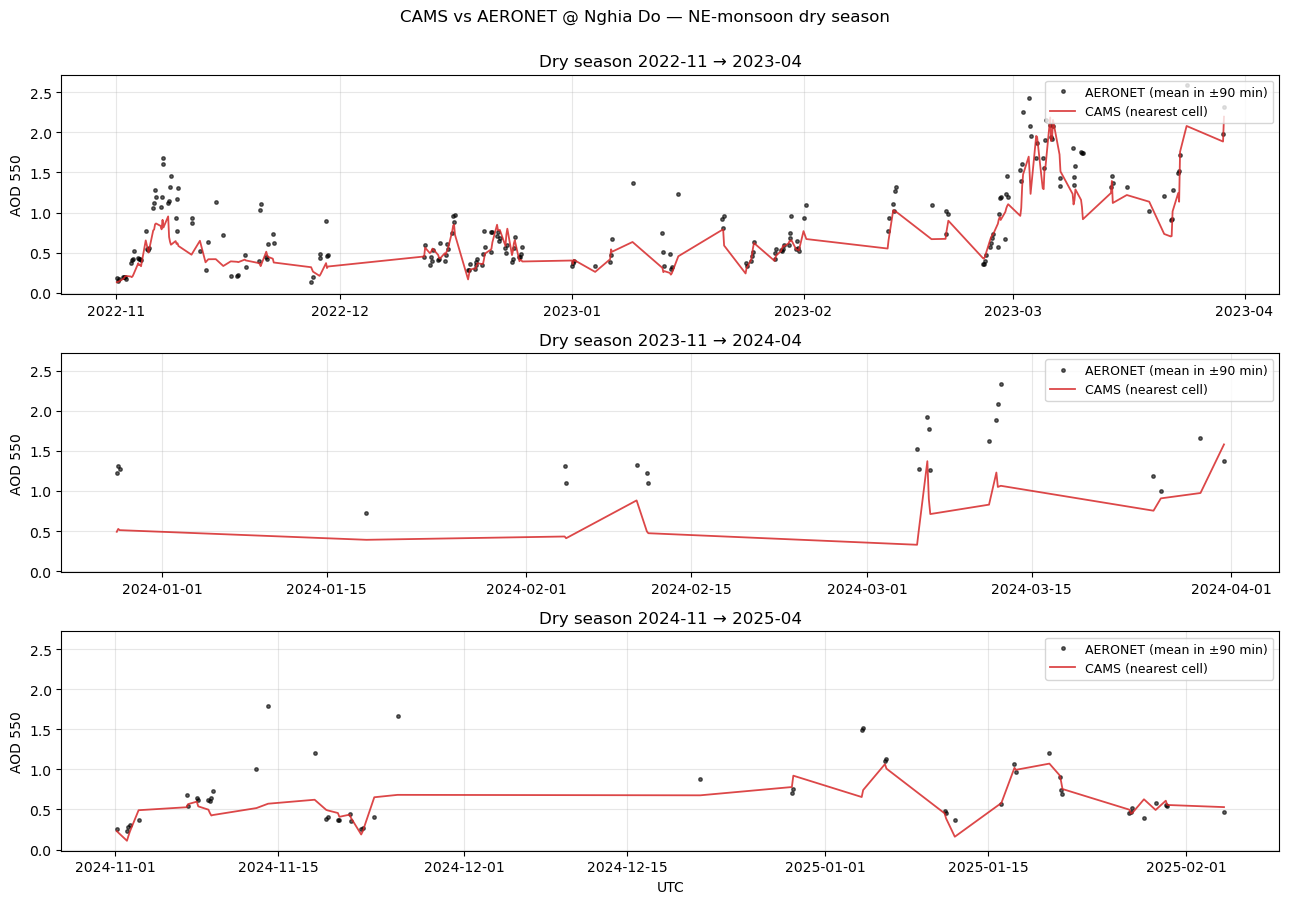

In [7]:
seasons = [("2022-11-01", "2023-04-01"),
           ("2023-11-01", "2024-04-01"),
           ("2024-11-01", "2025-04-01")]

fig, axes = plt.subplots(len(seasons), 1, figsize=(13, 3.0 * len(seasons)),
                         sharey=True)
if len(seasons) == 1:
    axes = [axes]

for ax, (s, e) in zip(axes, seasons):
    sub = pairs[(pairs.time_utc >= s) & (pairs.time_utc < e)]
    if sub.empty:
        ax.set_title(f"{s[:7]} — {e[:7]}  (no data)")
        continue
    ax.plot(sub.time_utc, sub.aeronet_aod, "o", ms=2.5, color="black",
            alpha=0.6, label="AERONET (mean in ±90 min)")
    ax.plot(sub.time_utc, sub.model_aod, "-", color="tab:red", lw=1.3,
            alpha=0.85, label="CAMS (nearest cell)")
    ax.set_ylabel("AOD 550")
    ax.set_title(f"Dry season {s[:7]} → {e[:7]}")
    ax.grid(alpha=0.3)
    ax.legend(loc="upper right", fontsize=9)
axes[-1].set_xlabel("UTC")
fig.suptitle("CAMS vs AERONET @ Nghia Do — NE-monsoon dry season", y=1.00)
fig.tight_layout()


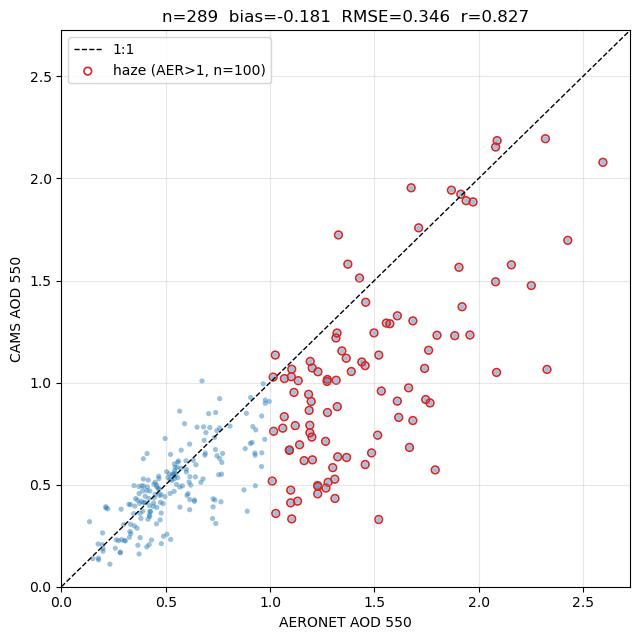

In [8]:
fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.scatter(pairs.aeronet_aod, pairs.model_aod, s=14, alpha=0.45, edgecolor="none")
m = max(pairs.aeronet_aod.max(), pairs.model_aod.max()) * 1.05
ax.plot([0, m], [0, m], "k--", lw=1, label="1:1")
# highlight haze episodes
haze = pairs[pairs.aeronet_aod > 1.0]
ax.scatter(haze.aeronet_aod, haze.model_aod, s=30, facecolor="none",
           edgecolor="tab:red", lw=1.2, label=f"haze (AER>1, n={len(haze)})")
ax.set_xlim(0, m); ax.set_ylim(0, m)
ax.set_xlabel("AERONET AOD 550"); ax.set_ylabel("CAMS AOD 550")
s = summarise(pairs)
ax.set_title(f"n={int(s['n'])}  bias={s['bias (CAMS-AER)']:+.3f}  "
             f"RMSE={s['RMSE']:.3f}  r={s['r']:.3f}")
ax.grid(alpha=0.3); ax.legend(loc="upper left")
fig.tight_layout()


# Per-stratum comparison: 2 sites × 2 seasons

Up to here we looked at Nghia Do during the NE-monsoon dry window only. Stage A
calibration uses the broader season split from `AOD_map/stage_a/config.py`:

- **dry** = Oct–Apr (`DRY_MONTHS`)
- **wet** = May–Sep (`WET_MONTHS`)

…over the two held-out AERONET sites:

- **NGHIA_DO** (21.048, 105.800) — north
- **Bac_Lieu**  (9.280, 105.730) — south

That gives **4 strata**. CAMS is the Stage B regional prior, so per-stratum
behaviour matters: a uniform CAMS bias is easy to absorb, but a wet/dry or
north/south flip points to a structural failure mode the downstream gap-fill
cannot rescue.

In [9]:
# import sys
# from pathlib import Path

# # Pull the canonical site list + season definitions straight from Stage A config
# # so this notebook can't drift from the calibration pipeline.
# sys.path.insert(0, str(Path("/home/work1/projects/Air_Quality/AOD_map/stage_a")))
# from config import AERONET_SITES, DRY_MONTHS as CFG_DRY, WET_MONTHS as CFG_WET

# SEASONS = {"dry": sorted(CFG_DRY), "wet": sorted(CFG_WET)}
# AERONET_DIR = Path("/home/slow_data/Air_Quality/AERONET/process/aod_550/10")

# # Build pairs for every (site, season) stratum, reusing the loaders defined above.
# pairs_by_stratum = {}
# for site, meta in AERONET_SITES.items():
#     csv = AERONET_DIR / f"{site}.csv"
#     aer = load_aeronet(csv)
#     aer = aer[(aer.time_utc >= DATE_START) & (aer.time_utc <= DATE_END)]

#     cam = load_cams_at_point(CAMS_GLOB, meta["lat"], meta["lon"])
#     cam = cam[(cam.time_utc >= DATE_START) & (cam.time_utc <= DATE_END)]

#     for season, months in SEASONS.items():
#         aer_s = aer[aer.time_utc.dt.month.isin(months)]
#         cam_s = cam[cam.time_utc.dt.month.isin(months)]
#         p = pair_observations(aer_s, cam_s, tolerance_minutes=90)
#         pairs_by_stratum[(site, season)] = p
#         print(f"  {site:10s} {season}: {len(p):4d} paired obs "
#               f"(AERONET {len(aer_s):,} / CAMS {len(cam_s):,})")

In [10]:
# # Per-stratum summary: same metrics as `summarise()` but indexed by (site, season).
# summary_rows = []
# for (site, season), p in pairs_by_stratum.items():
#     if len(p) == 0:
#         continue
#     s = summarise(p)
#     s.name = f"{site} | {season}"
#     summary_rows.append(s)

# summary_df = pd.concat(summary_rows, axis=1).T
# summary_df.index.name = "stratum"
# summary_df.round(3)

## Residual envelope plot

For each stratum, plot the residual `r = CAMS − AERONET` against `AERONET AOD`
and draw an envelope so the structure of the error (not just a single
RMSE/bias number) is visible.

Two questions we want the envelope to answer:

1. **Is CAMS biased only at one end of the AOD range?**  The Nghia Do
   case study showed CAMS-AOD is fine at low loadings but collapses to
   ~−0.4 during haze (AER > 1).  We want to see whether the wet seasons
   and the southern site share that pattern or have a different signature.
2. **Is the spread inside an expected-error envelope?**  Stage A uses the
   Sayer/Levy form `EE = ±(0.05 + slope·AOD_ref)`.  Overlaying it tells us
   whether CAMS sits inside the satellite-grade envelope, or whether the
   regional prior is noisier than the retrievals it is meant to
   regularise.

The choice of *how* to bin and what bands to draw shapes the readability of
the plot, so the binning function is the next cell — see the TODO.

In [11]:
# def residual_envelope(aer, res, bin_edges, min_count=10):
#     """Bin residuals by AERONET AOD and return median + spread bands.

#     Parameters
#     ----------
#     aer : np.ndarray  — AERONET AOD (x axis)
#     res : np.ndarray  — residual CAMS − AERONET (y axis)
#     bin_edges : np.ndarray  — monotonically increasing bin edges on the AOD axis
#     min_count : int   — drop bins with fewer samples than this (too noisy)

#     Returns
#     -------
#     pd.DataFrame with one row per surviving bin and columns:
#         aod_centre, n, med, lo, hi

#     The interpretation of `lo`/`hi` is the design choice — see TODO below.
#     """
#     # TODO (yours): implement the binning.  Suggested 5–10 lines.
#     #
#     # Decisions to make:
#     #   (a) Bin centre — geometric mean (good for log-spaced edges) or
#     #       arithmetic mean of AERONET AOD inside the bin?
#     #   (b) Spread band — ±1σ (parametric, sensitive to outliers) OR the
#     #       16th/84th percentiles (non-parametric, robust to the haze tail)?
#     #       Stage A's TC σ² lives in the parametric world, so ±1σ is more
#     #       comparable to the EE envelope; percentiles read better when the
#     #       residual distribution is skewed (which it is at haze AODs).
#     #   (c) How to skip undersampled bins — return them with NaNs so the
#     #       caller can ignore them, or drop them entirely?
#     #
#     # Pseudocode:
#     #   idx = np.digitize(aer, bin_edges) - 1
#     #   for each bin i in range(len(bin_edges)-1):
#     #       mask = (idx == i)
#     #       if mask.sum() < min_count: continue
#     #       centre = aer[mask].mean()         # or np.exp(np.log(aer[mask]).mean())
#     #       med    = np.median(res[mask])
#     #       lo, hi = np.percentile(res[mask], [16, 84])   # or mean ± std
#     #       rows.append((centre, mask.sum(), med, lo, hi))
#     #   return pd.DataFrame(rows, columns=["aod_centre","n","med","lo","hi"])
#     raise NotImplementedError("Fill in residual_envelope() before running the plot.")

In [12]:
# # 2 × 2 envelope grid: rows=site, cols=season.
# # AOD axis is log-spaced because the AERONET PDF is heavy-tailed (haze events).
# BIN_EDGES = np.geomspace(0.03, 3.0, 13)

# # Sayer/Levy-style EE envelope for reference: ±(0.05 + slope·AOD).
# # CAMS isn't in config.SENSOR_EE_SLOPE; pick the MODIS DT slope (0.15) as the
# # conservative reference — CAMS is a reanalysis, not a satellite retrieval, so
# # this is "would CAMS pass as a MODIS-grade product".
# EE_OFFSET, EE_SLOPE = 0.05, 0.15

# sites   = list(AERONET_SITES.keys())
# seasons = list(SEASONS.keys())

# fig, axes = plt.subplots(len(sites), len(seasons),
#                          figsize=(11, 4.0 * len(sites)),
#                          sharex=True, sharey=True)

# for i, site in enumerate(sites):
#     for j, season in enumerate(seasons):
#         ax = axes[i, j]
#         p = pairs_by_stratum[(site, season)]
#         if len(p) == 0:
#             ax.set_title(f"{site} | {season} (no data)")
#             continue

#         aer = p["aeronet_aod"].to_numpy()
#         res = (p["model_aod"] - p["aeronet_aod"]).to_numpy()

#         # raw scatter
#         ax.scatter(aer, res, s=8, alpha=0.25, edgecolor="none", color="tab:blue")

#         # binned envelope
#         env = residual_envelope(aer, res, BIN_EDGES, min_count=10)
#         ax.plot(env["aod_centre"], env["med"], "-", color="tab:red", lw=1.6,
#                 label="median residual")
#         ax.fill_between(env["aod_centre"], env["lo"], env["hi"],
#                         color="tab:red", alpha=0.20, label="16–84% spread")

#         # EE reference envelope (CAMS − AER expected band if CAMS were MODIS-grade)
#         x = np.linspace(0, BIN_EDGES[-1], 100)
#         ee = EE_OFFSET + EE_SLOPE * x
#         ax.plot(x,  ee, "k--", lw=0.8, alpha=0.7)
#         ax.plot(x, -ee, "k--", lw=0.8, alpha=0.7, label="±EE (0.05+0.15·AOD)")

#         ax.axhline(0, color="k", lw=0.6)
#         ax.set_xscale("log")
#         ax.set_xlim(BIN_EDGES[0], BIN_EDGES[-1])
#         ax.set_title(f"{site} | {season}  (n={len(p)})")
#         ax.grid(alpha=0.3, which="both")
#         if i == len(sites) - 1:
#             ax.set_xlabel("AERONET AOD 550 (log)")
#         if j == 0:
#             ax.set_ylabel("CAMS − AERONET")
#         if i == 0 and j == 0:
#             ax.legend(loc="lower left", fontsize=8)

# fig.suptitle("CAMS − AERONET residual envelope per stratum", y=1.00)
# fig.tight_layout()